# Chapter 7: Generating High-Resolution Images with Diffusion Models




Open in Colab:    
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/189bX_biF4fEBNuwFUf1NPR8d8kGVwNU1?usp=sharing)


This chapter covers

* The DDIM noise scheduler
* Adding the attention mechanism in denoising U-Net models
* Generating high-resolution images with diffusion models
* Interpolating initial noise tensors to generate composite images

In the previous two chapters, you explored the fundamentals of diffusion models. You learned how these models use a forward diffusion process, where we gradually add noise to clean images until they are transformed into pure noise, and a reverse diffusion process, where a trained model reconstructs images by progressively removing noise. A key component of this process is the denoising U-Net model, which learns to clean up noisy images until the final output is indistinguishable from real images in the training dataset.

Once the model is trained, you can start with a completely random noise tensor and use the U-Net to iteratively remove noise, eventually generating a clear and meaningful image. Additionally, diffusion models can be conditioned on specific information—such as labels or text—to guide the image generation process. This conditional generation is crucial because modern text-to-image models rely on conditioning mechanisms to create images based on text prompts.

To keep things simple and computationally manageable, we used grayscale images of clothing items in the previous two chapters. To generate high-resolution images, say, 64x64 pixel RGB images, we need to build and train more advanced models due to the increased complexity of the data. In this chapter, you will learn how to generate high-resolution color flower images using state-of-the-art diffusion techniques.

One key improvement we introduce is a new and more efficient noise scheduler, known as denoising diffusion implicit models (DDIM). In the previous chapters, you worked with denoising diffusion probabilistic models (DDPM), which generate images through a randomized (stochastic) process and follow a Markovian process, meaning each step depends only on the immediate previous step. While effective, this method can require many steps to produce high-quality images.
In contrast, DDIM takes a more direct and predictable approach. It uses a deterministic, non-Markovian process, allowing it to generate images in fewer steps without sacrificing quality. This makes DDIM significantly more efficient than DDPM, an important advancement for generating high-resolution images quickly.

Compared to the simple U-Net model we built from scratch in chapter 6, we introduce two key improvements to the denoising U-Net model in this chapter to enhance its ability to generate high-resolution images. One major improvement is the addition of more downsampling and upsampling layers in the U-Net. These extra layers allow the model to capture fine-grained details from the input image. Downsampling layers help the network break down the image into different levels of abstraction, identifying both high-level and low-level features. The upsampling layers then reconstruct the image by progressively refining these details, leading to a more realistic output.

However, increasing the model’s depth and complexity also introduces a challenge: with so much information being processed, it becomes harder for the model to identify the most relevant features—like trying to find a needle in a haystack. Without an efficient way to focus on critical details, the model may struggle to generate clear and meaningful images. To address this challenge, we integrate the scaled dot product attention (SDPA) mechanism into the U-Net (the same attention mechanism we used in chapter 2 when translating German to English). Attention mechanisms allow the model to selectively focus on important features in an image while ignoring less relevant details.

Once we have trained our denoising model, we can generate high-resolution images by feeding an initial noise tensor into the U-Net. This noise tensor acts as a starting point, and the model gradually refines it into a clear, detailed image. Since the process is influenced by the specific noise tensor we provide, different initial noise tensors will result in different final images. For example, one noise tensor might lead to the generation of a white lily, while another might produce a yellow aster.
To illustrate how the choice of initial noise affects the final image, we will interpolate between two different noise tensors. This means we will blend the two noise tensors in varying proportions to create new, intermediate noise tensors. By assigning different weights to each original noise tensor, we can generate a smooth transition from one image to another.

For instance, if we start with a noise tensor that produces a white lily and another that produces a yellow aster, we can create a sequence of intermediate images by gradually shifting the balance between the two tensors. Feeding each of these blended noise tensors into the trained U-Net results in composite images that slowly change from one flower to the other. This step-by-step transition visually demonstrates how the initial noise influences the final output, reinforcing the core concept of controlled image generation in diffusion models.

# 1. Attention in U-Net, DDIM, and image interpolation

# 2. High-resolution flower images as training data
## 2.1	Visualize Images in the training dataset

The Python programs in this chapter are adapted from Hugging Face’s GitHub repository https://github.com/huggingface/diffusers and Filip Basara's GitHub repository https://github.com/filipbasara0/simple-diffusion. 

In [1]:
!pip install --upgrade datasets einops diffusers

In [2]:
from datasets import load_dataset
from torchvision.transforms import (CenterCrop,
    Compose,InterpolationMode,RandomHorizontalFlip,
    Resize,ToTensor)

resolution=64

augmentations = Compose([
    Resize(resolution, 
    interpolation=InterpolationMode.BILINEAR),
    CenterCrop(resolution),
    RandomHorizontalFlip(),
    ToTensor(),])    #A 

def transforms(examples):
    images = [augmentations(image.convert("RGB"))
        for image in examples["image"]]
    return {"input": images}

dataset = load_dataset("huggan/flowers-102-categories",
    split="train",)    #B    
dataset.set_transform(transforms)    #C
#A Define several image augmentation methods
#B Download the data from Hugging Face directly
#C Perform image transformations

In [3]:
import torch

torch.manual_seed(42)
batch_size=4
train_dataloader=torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True)

Next, we use the matplotlib library to visualize some examples of the flower images in the dataset:


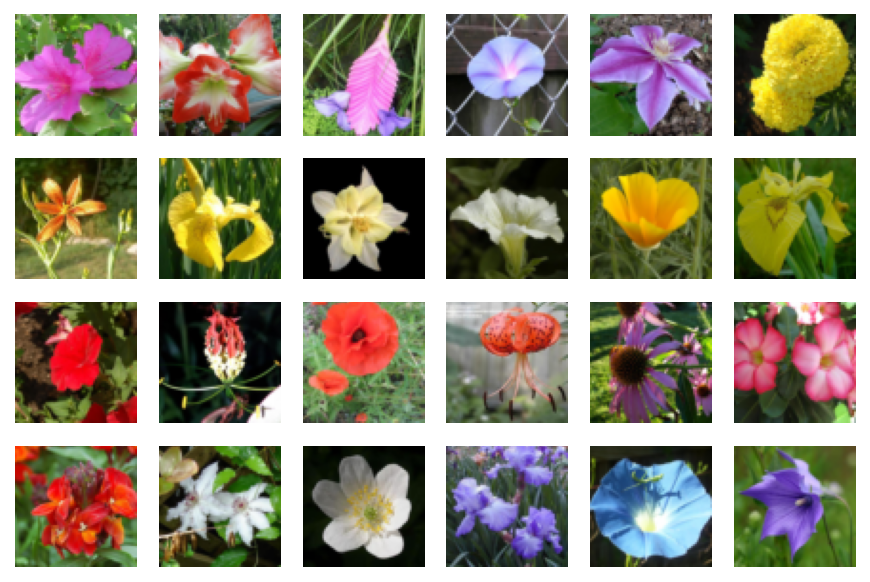

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5.9,batch_size),dpi=150)
for col in range(6):    #A 
    imgs=next(iter(train_dataloader))["input"]
    for row in range(batch_size):
        plt.subplot(batch_size,6,col+1+row*6)
        img=imgs[row].permute(1,2,0)    #B
        plt.imshow(torch.clip(img,0,1))    #C
        plt.axis('off')
plt.tight_layout()
plt.show()
#A Plot sample images in four rows and six columns
#B Change from channel first to channel last
#C Clip image values so they fall in the range [0, 1]

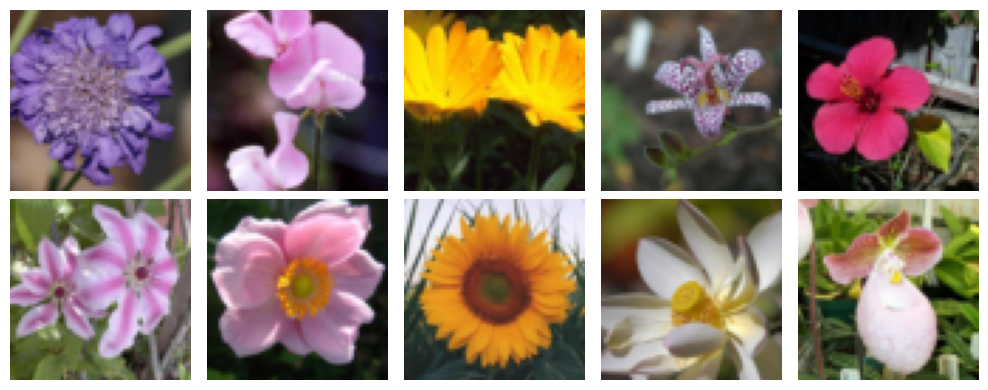

In [5]:
# answer to exercise 1
plt.figure(figsize=(10,4),dpi=100)
for col in range(5):    
    imgs=next(iter(train_dataloader))["input"]
    for row in range(2):
        plt.subplot(2,5,col+1+row*5)
        img=imgs[row].permute(1,2,0)    
        plt.imshow(torch.clip(img,0,1))    
        plt.axis('off')
plt.tight_layout()
plt.show()

## 3.2.	Forward Diffusion on Flower Images


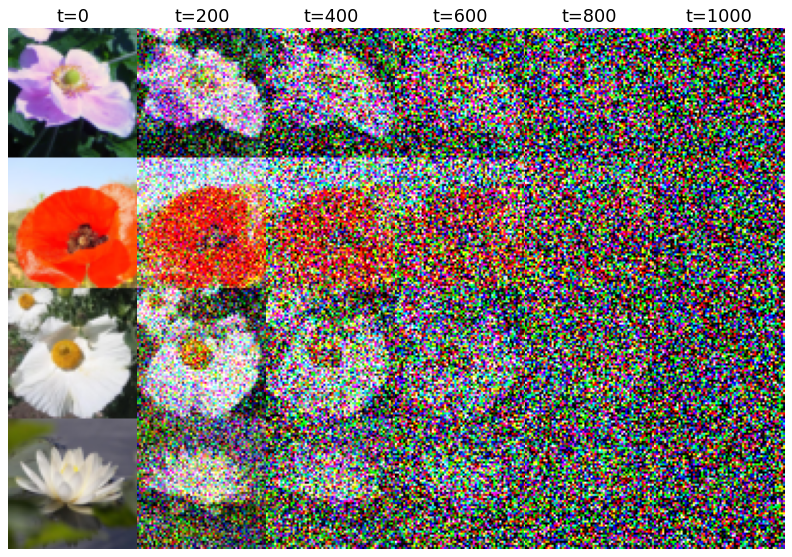

In [6]:
from utils.ddim_util import DDIMScheduler
noise_scheduler=DDIMScheduler(num_train_timesteps=1000)

imgs=next(iter(train_dataloader))["input"]
imgs=imgs.permute(0,2,3,1).reshape(-1,64,3)    #A 

allimgs=[imgs]
for step in [200,400,600,800,1000]:    #B
    timesteps=torch.tensor([step-1]).long()
    noisy_image=noise_scheduler.add_noise(imgs,
         torch.randn(imgs.shape), timesteps)
    allimgs.append(noisy_image)
plt.figure(figsize=(10,8),dpi=80)
for i in range(6):    #C
    plt.subplot(1,6,i+1)
    plt.imshow(torch.clip(allimgs[i],0,1))
    plt.axis('off')
    plt.title(f"t={200*i}",fontsize=16)
plt.tight_layout(w_pad=-0.1)
plt.show()
#A Obtain a batch of images and change them to channel-last format
#B Create noisy images at time steps 200, 400, ..., 1000
#C Plot them iamges in a 4x6 grid

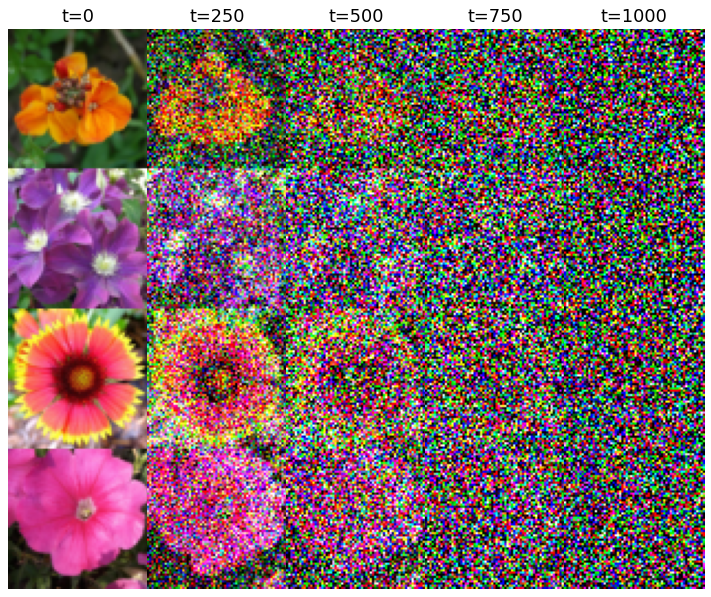

In [7]:
# exercise 2
imgs=next(iter(train_dataloader))["input"]
imgs=imgs.permute(0,2,3,1).reshape(-1,64,3)    
allimgs=[imgs]
for step in [250,500,750,1000]:    
    timesteps=torch.tensor([step-1]).long()
    noisy_image=noise_scheduler.add_noise(imgs,
         torch.randn(imgs.shape), timesteps)
    allimgs.append(noisy_image)
plt.figure(figsize=(9,8),dpi=80)
for i in range(5):    
    plt.subplot(1,5,i+1)
    plt.imshow(torch.clip(allimgs[i],0,1))
    plt.axis('off')
    plt.title(f"t={250*i}",fontsize=16)
plt.tight_layout(w_pad=-0.1)
plt.show()

# 3. Build and Train a Denoising U-Net Model

## 3.1 Build the denoising U-Net model
In the local module file ddim_util.py, we define the U-Net model. In particular, the file contains a sinusoidal_embedding() function as follows to embed the time step information:

```python
def sinusoidal_embedding(timesteps, dim):
    half_dim = dim // 2
    exponent = -math.log(10000) * torch.arange(
        start=0, end=half_dim, dtype=torch.float32)
    exponent = exponent / (half_dim - 1.0)
    emb = torch.exp(exponent).to(device=timesteps.device)
    emb = timesteps[:, None].float() * emb[None, :]
    return torch.cat([emb.sin(), emb.cos()], dim=-1)
```

To implement the attention mechanism, we have defined an Attention() class in the local module ddim_util.py, as shown below:

```python
class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)
    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, m=1)    #A
        q, k, v = map(
        lambda t: rearrange(t, 'b (h c) x y -> b h c (x y)', h=self.heads),
      qkv)    #B
        q = q * self.scale    
        sim = einsum('b h d i, b h d j -> b h i j', q, k)
        attn = sim.sofax(dim=-1)    #C
        out = einsum('b h i j, b h d j -> b h i', attn, v)    #D
        out = rearrange(out, 'b h (x y) d -> b (h d) x y', x=h, y=w)
        return self.to_out(out)    #E
print(out.shape)
```

This is the standard SDPA mechanism that we often use in Transformers and natural language processing (NLP). We create a denoising U-Net model as follows:

In [8]:
from utils.ddim_util import UNet

device="cuda" if torch.cuda.is_available() else "cpu"
resolution=64
model=UNet(3,hidden_dims=[128,256,512,1024],
           image_size=resolution).to(device)
num=sum(p.numel() for p in model.parameters())
print("number of parameters: %.2fM" % (num/1e6,))

number of parameters: 133.42M


## 3.2 Train the denoising U-Net model
We'll train the model for 100 epochs. The optimizer and the learning rate scheduler are defined below.

In [9]:
from diffusers.optimization import get_scheduler

optimizer=torch.optim.AdamW(model.parameters(),lr=0.0001,
    betas=(0.95,0.999),weight_decay=0.00001,eps=1e-8)    #A
lr_scheduler=get_scheduler(    #B
    "cosine",
    optimizer=optimizer,
    num_warmup_steps=300,
    num_training_steps=(len(train_dataloader) * 100))

Next, we train the model with the data we prepared earlier. 

In [10]:
for epoch in range(100):
    model.train()
    tloss = 0
    print(f"start epoch {epoch}")
    for step, batch in enumerate(train_dataloader):
        clean_images = batch["input"].to(device)*2-1
        nums = clean_images.shape[0]
        noise = torch.randn(clean_images.shape).to(device)
        timesteps = torch.randint(0,
                noise_scheduler.num_train_timesteps,
                (nums, ),
                device=device).long()
        noisy_images = noise_scheduler.add_noise(clean_images,
                     noise, timesteps)

        noise_pred = model(noisy_images, timesteps)["sample"]
        loss = torch.nn.functional.l1_loss(noise_pred, noise)
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        tloss += loss.detach().item()
        if step%100==0:
            print(f"step {step}, average loss {tloss/(step+1)}")
torch.save(model.state_dict(),'files/diffusion.pth')

# 4. Image Generation and Interpolation 
 
## 4.1 Use the Trained Denoising U-Net to Generate Images
We have defined the following generate() method in the DDIMScheduler() class in ddim_util.py:

```python
@torch.no_grad()
def generate(self,model,device,batch_size=1,generator=None,
     eta=1.0,use_clipped_model_output=True,num_inference_steps=50):
    # save intermediate steps
    imgs=[]
    # the initial random noise
    image=torch.randn((batch_size,model.in_channels,model.sample_size,
        model.sample_size),generator=generator).to(device)
    self.set_timesteps(num_inference_steps)
    # start denoising
    for t in tqdm(self.timesteps):
        model_output = model(image, t)["sample"]
        image = self.step(model_output,t,image,eta,
              use_clipped_model_output=use_clipped_model_output)
        img = unnormalize_to_zero_to_one(image)
        img = img.cpu().permute(0, 2, 3, 1).numpy()
        imgs.append(img)
    # output the final clean image and the intermediate steps    
    image = unnormalize_to_zero_to_one(image)
    image = image.cpu().permute(0, 2, 3, 1).numpy()
    return image, imgs
```

The method feeds a random noise tensor to the trained model to denoise it iteratively. We have chosen 50 inference steps. The model generates the images in time steps t=980, 960,…, 20, and 0. Each inference step is equivalent to 20 time steps since 1000/50=20. 

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:58<00:00,  1.17s/it]


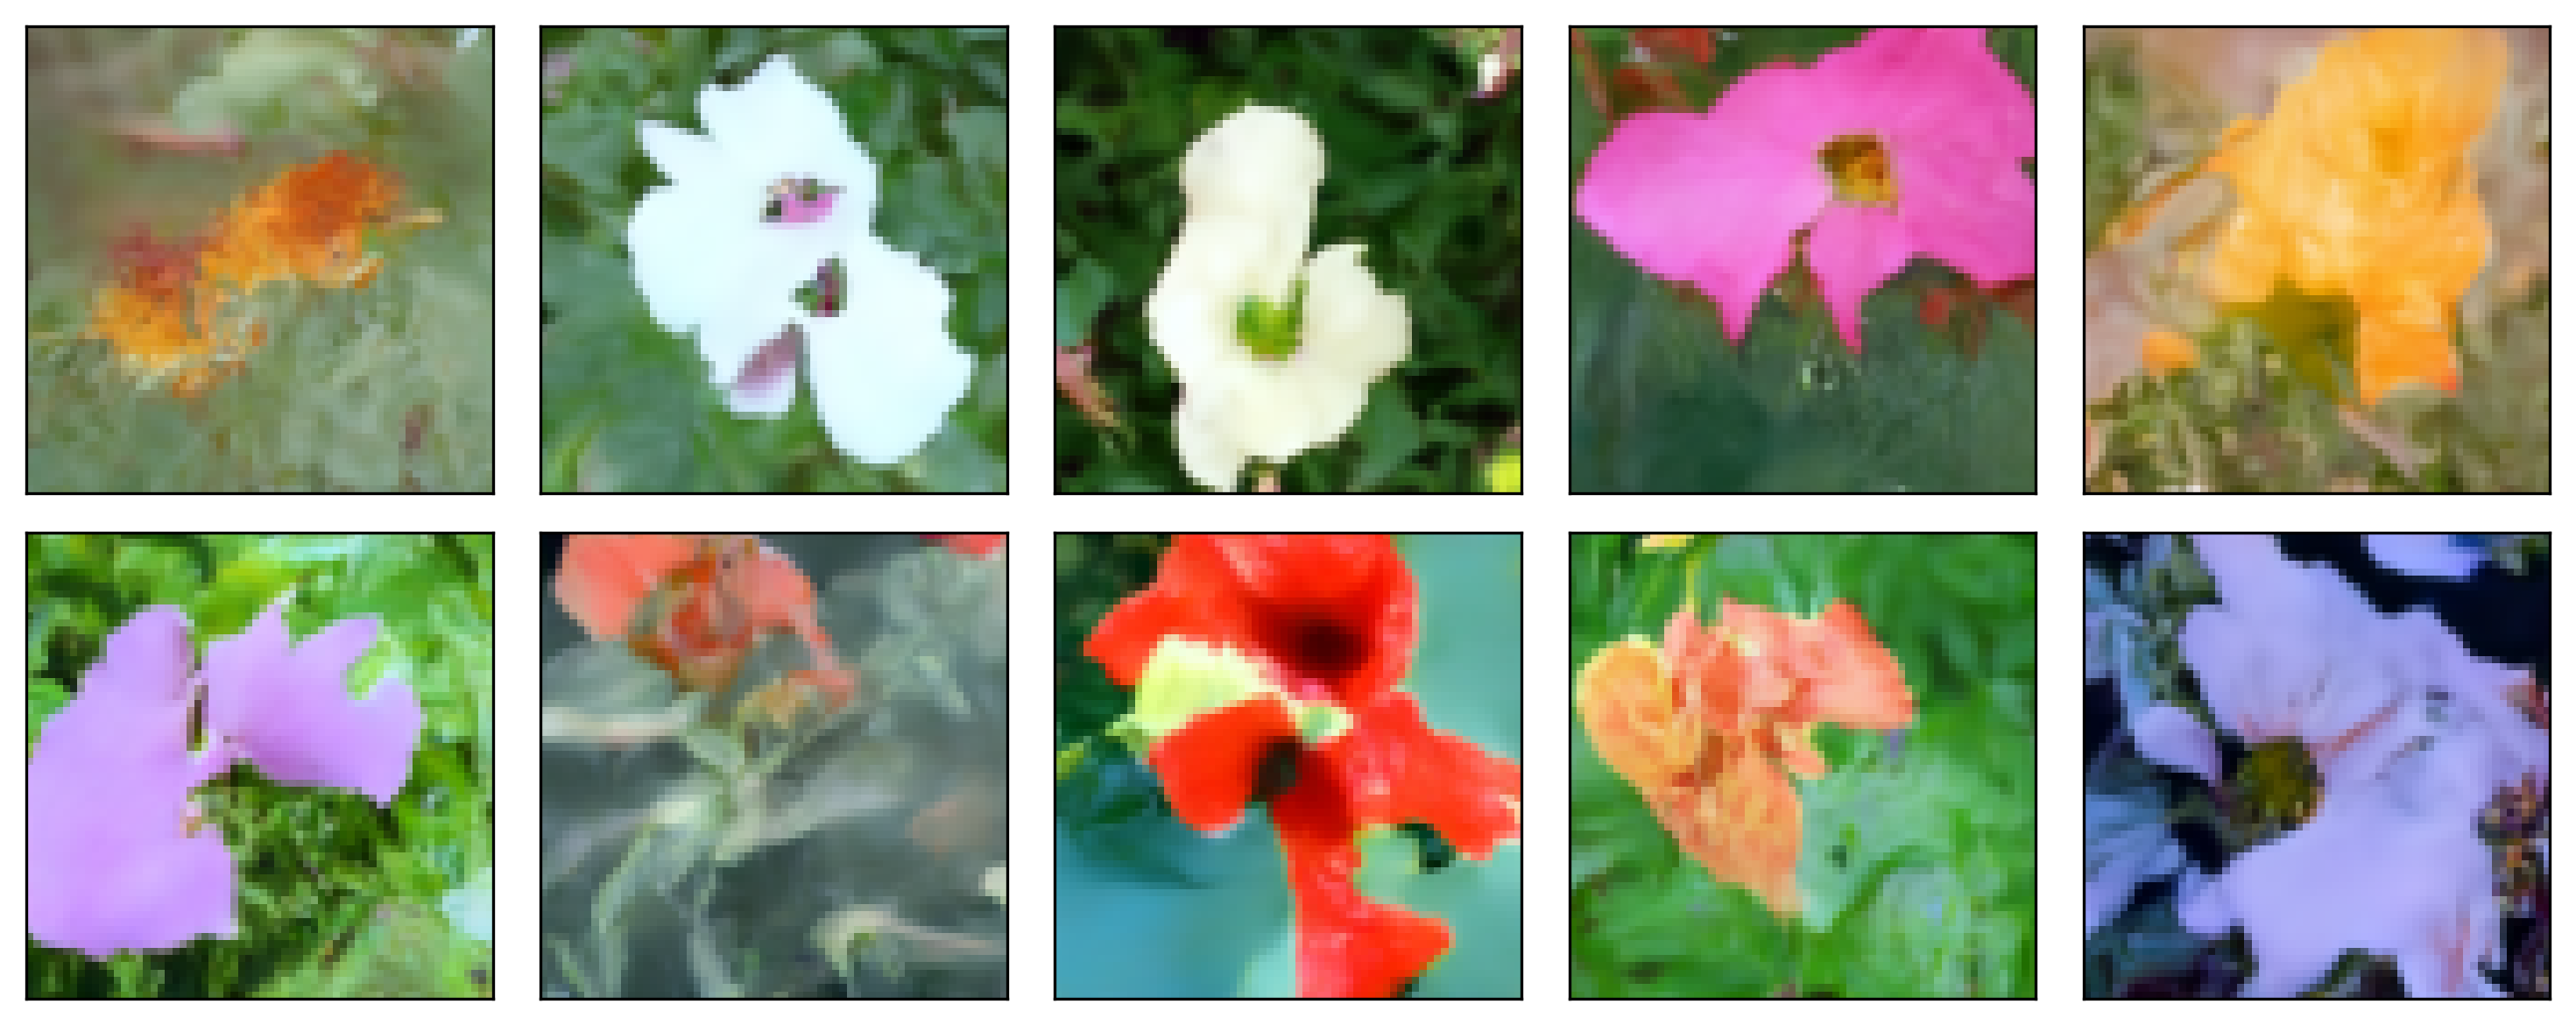

In [11]:
sd=torch.load('files/diffusion.pth',weights_only=True)

model.load_state_dict(sd)
with torch.no_grad():
    generator = torch.manual_seed(100)
    generated_images,imgs = noise_scheduler.generate(
        model,device=device,
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10)
imgnp=generated_images

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4),dpi=100)
for i in range(10):
    ax = plt.subplot(2,5, i + 1)
    plt.imshow(imgnp[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:57<00:00,  1.15s/it]


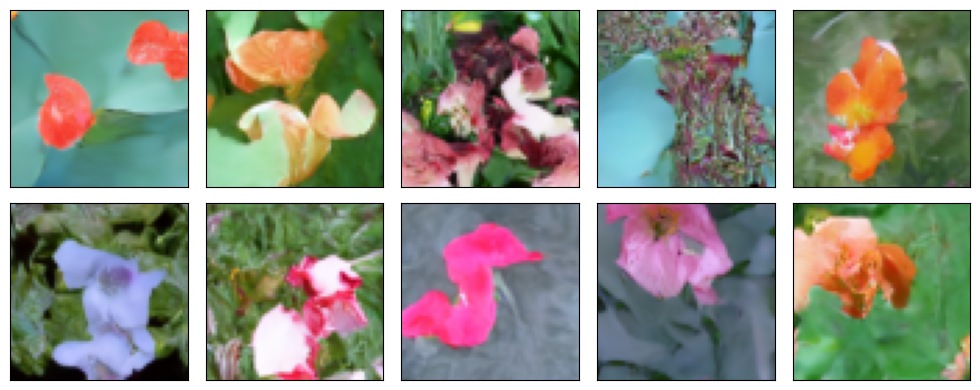

In [12]:
# exercise 3
with torch.no_grad():
    generator = torch.manual_seed(42)
    generated_images,imgs = noise_scheduler.generate(
        model,device=device,
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10)
imgnp=generated_images

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4),dpi=100)
for i in range(10):
    ax = plt.subplot(2,5, i + 1)
    plt.imshow(imgnp[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

## 4.2 Transition from One Image to Another
We have defined the following interpolate() method in the DDIMScheduler() class in ddim_util.py:

```python
@torch.no_grad()
def interpolate(self,model,a_idx,b_idx,batch_size=1,generator=None,
    eta=1.0,use_clipped_model_output=True,num_inference_steps=50,
             device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    image0 = torch.randn((batch_size, model.in_channels, 
      model.sample_size, model.sample_size),generator=generator,
                         ).to(device)
    image = torch.zeros((batch_size, model.in_channels, 
      model.sample_size, model.sample_size)).to(device)
    # pick two initial noise tensors
    a,b=image0[a_idx],image0[b_idx]
    # interpolate with different weights
    for i in range(10):
        ab=torch.sin(torch.tensor(0.5*math.pi*(0.05+i/10)))*a+\
            torch.cos(torch.tensor(0.5*math.pi*(0.05+i/10)))*b
        image[i]=ab
    self.set_timesteps(num_inference_steps)
    # generate 
    for t in tqdm(self.timesteps):
        model_output = model(image, t)["sample"]
        image = self.step(model_output,t,image,eta,
          use_clipped_model_output=use_clipped_model_output,
                          generator=generator)
    image = unnormalize_to_zero_to_one(image)
    image = image.cpu().permute(0, 2, 3, 1).numpy()
    return image
```

Let's create a series of images that gradually transition from the second image to the eighth image:

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:56<00:00,  1.13s/it]


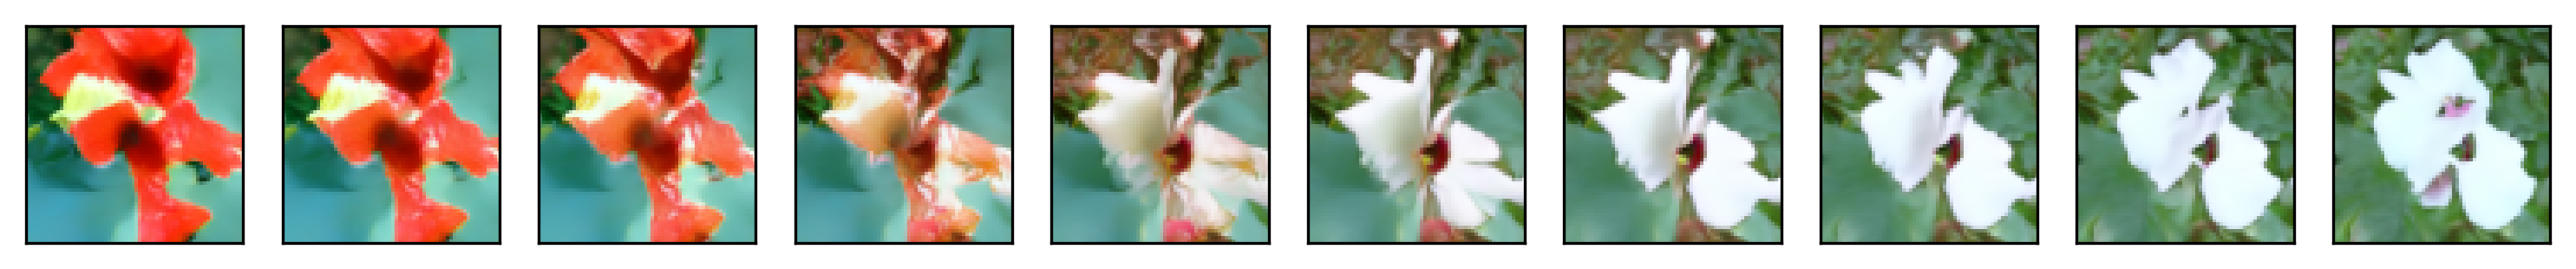

In [13]:
with torch.no_grad():
    generator = torch.manual_seed(100)
    generated_images = noise_scheduler.interpolate(
        model,1,7,
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10)
    
imgnp=generated_images 

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4),dpi=100)
for i in range(10):
    ax = plt.subplot(1,10, i + 1)
    plt.imshow(imgnp[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:56<00:00,  1.13s/it]


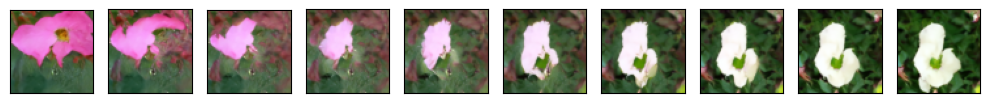

In [14]:
# exercise 4
with torch.no_grad():
    generator = torch.manual_seed(100)
    generated_images = noise_scheduler.interpolate(
        model,2,3,
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10)
    
imgnp=generated_images 

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4),dpi=100)
for i in range(10):
    ax = plt.subplot(1,10, i + 1)
    plt.imshow(imgnp[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

In [15]:
with torch.no_grad():
    generator = torch.manual_seed(100)
    generated_images = noise_scheduler.interpolate(
        model,2,5,
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10)
imgnp1=generated_images
with torch.no_grad():
    generator = torch.manual_seed(100)
    generated_images = noise_scheduler.interpolate(
        model,7,2,
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10)
imgnp2=generated_images
with torch.no_grad():
    generator = torch.manual_seed(100)
    generated_images = noise_scheduler.interpolate(
        model,3,1,
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10)
imgnp3=generated_images 

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:56<00:00,  1.12s/it]


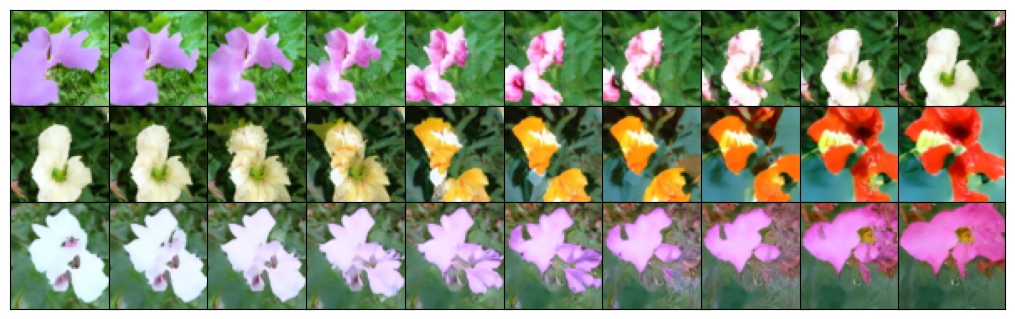

In [16]:
import numpy as np
img_array=np.concatenate([imgnp1,imgnp2,imgnp3])
fig, axs = plt.subplots(nrows=3, 
            ncols=10,sharex=True,
            sharey=True,figsize=(10,3),dpi=100)
for row in range(3):
    for col in range(10):
        axs[row, col].clear()
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])
        axs[row, col].imshow(img_array[col+row*10])
plt.subplots_adjust(bottom=0.001,right=0.999,top=0.999,
left=0.001, hspace=-0.1,wspace=-0.1)